In [23]:
import sys
from pathlib import Path

# Add project root to Python path so we can import trace package
project_root = Path().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Verify trace package can be found
try:
    import trace
    print(f"✓ Found trace package at: {trace.__file__}")
except ImportError as e:
    print(f"✗ Error importing trace: {e}")
    print(f"  Current working directory: {Path.cwd()}")
    print(f"  Project root: {project_root}")
    print(f"  Python path: {sys.path[:3]}...")
    raise

from trace.statistics import compute_rd_pvalues
import pandas as pd
print("✓ Successfully imported compute_rd_pvalues")


✓ Found trace package at: /Users/mariaelkjaermontgomery/Library/CloudStorage/Dropbox/phd/trace_paper/trace_paper/trace/__init__.py
✓ Successfully imported compute_rd_pvalues


In [24]:
binary_df = pd.read_csv('data/love_plot/diab/raw_binary.txt')
binary_df_weighted = pd.read_csv('data/love_plot/diab/raw_binary_weighted.txt')

In [25]:
binary_df

,Unnamed: 0,criterion,group,count,percentage
0,0,ace_inhibitors,Control,2962,12.896
1,1,ace_inhibitors,Exposed,1173,13.048
2,2,ace_inhibitors,Overall,4135,12.938
3,3,angiotensin_ii_receptor_blockers,Control,2938,12.791
4,4,angiotensin_ii_receptor_blockers,Exposed,1436,15.973
...,...,...,...,...,...
184,184,type2_diabetes,Exposed,8858,98.532
185,185,type2_diabetes,Overall,28728,89.890
186,186,unstable_angina_pectoris,Control,193,0.840
187,187,unstable_angina_pectoris,Exposed,118,1.313


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


In [27]:
def calculate_smd_binary(p1, p2):
    """
    Calculate standardized mean difference (SMD) for binary variables.
    
    Parameters
    ----------
    p1 : float
        Proportion in group 1 (Control) as percentage (0-100)
    p2 : float
        Proportion in group 2 (Exposed) as percentage (0-100)
    
    Returns
    -------
    float
        Standardized mean difference
    """
    # Convert percentages to proportions
    p1_prop = p1 / 100.0
    p2_prop = p2 / 100.0
    
    # Calculate pooled standard deviation
    pooled_std = np.sqrt((p1_prop * (1 - p1_prop) + p2_prop * (1 - p2_prop)) / 2)
    
    # Avoid division by zero
    if pooled_std == 0:
        return 0.0
    
    # Calculate SMD
    smd = (p1_prop - p2_prop) / pooled_std
    
    return smd


In [28]:
# df is your input dataframe
pivot = binary_df.pivot(index='criterion', columns='group', values='percentage')

pivot['diff_exposed_control'] = pivot['Exposed'] - pivot['Control']
pivot = pivot.sort_values('diff_exposed_control')
pivot

group,Control,Exposed,Overall,diff_exposed_control
criterion,,,,
atrial_fibrillation_flutter,9.360,7.008,8.699,-2.352
anticoagulants,12.007,9.711,11.361,-2.296
heart_failure,6.670,4.683,6.111,-1.987
cardiovascular_mortality,40.137,38.932,39.798,-1.205
history_stroke_tia,5.216,4.182,4.925,-1.034
...,...,...,...,...
metformin,41.077,55.784,45.214,14.707
diabetes_icd10,36.401,51.891,40.758,15.490
sglt2_inhibitors,6.500,21.991,10.858,15.491


In [29]:
# df is your input dataframe
pivot_weighted = binary_df_weighted.pivot(index='criterion', columns='group', values='percentage')
pivot_weighted['diff_exposed_control'] = pivot_weighted['Exposed'] - pivot_weighted['Control']
pivot_weighted = pivot_weighted.sort_values('diff_exposed_control')
pivot_weighted

group,Control,Exposed,Overall,diff_exposed_control
criterion,,,,
atrial_fibrillation_flutter,9.299,7.008,8.356,-2.291
anticoagulants,11.969,9.711,11.040,-2.258
heart_failure,6.645,4.683,5.838,-1.962
cardiovascular_mortality,40.077,38.932,39.606,-1.145
history_stroke_tia,5.250,4.182,4.811,-1.068
...,...,...,...,...
diabetes_icd10,36.408,51.891,42.777,15.483
sglt2_inhibitors,6.498,21.991,12.871,15.493
diabetes,65.017,84.538,73.047,19.521


In [45]:
def compute_smd(df):
    # df is pivoted like your pivot or pivot_weighted
    p1 = df['Exposed']
    p0 = df['Control']
    pooled_sd = ((p1*(1-p1) + p0*(1-p0)) / 2) ** 0.5
    df['smd'] = (p1 - p0) / pooled_sd
    return df


pivot[['Exposed', 'Control']] = pivot[['Exposed', 'Control']] / 100
pivot_weighted[['Exposed', 'Control']] = pivot_weighted[['Exposed', 'Control']] / 100

pivot_smd = compute_smd(pivot).sort_values('smd')
pivot_weighted_smd = compute_smd(pivot_weighted).sort_values('smd')

In [46]:
pivot_weighted_smd

group,Control,Exposed,Overall,diff_exposed_control,smd
criterion,,,,,
heart_failure,0.000664,0.000468,5.838,-1.962,-0.008246
atrial_fibrillation_flutter,0.000930,0.000701,8.356,-2.291,-0.008027
anticoagulants,0.001197,0.000971,11.040,-2.258,-0.006862
aortic_regurgitation_stenosis,0.000292,0.000190,2.503,-1.020,-0.006569
bradycardia,0.000108,0.000060,0.884,-0.480,-0.005234
...,...,...,...,...,...
insulin,0.001288,0.002465,17.724,11.766,0.027188
empagliflozin,0.000353,0.001266,7.286,9.126,0.032091
sglt2_inhibitors,0.000650,0.002199,12.871,15.493,0.041088


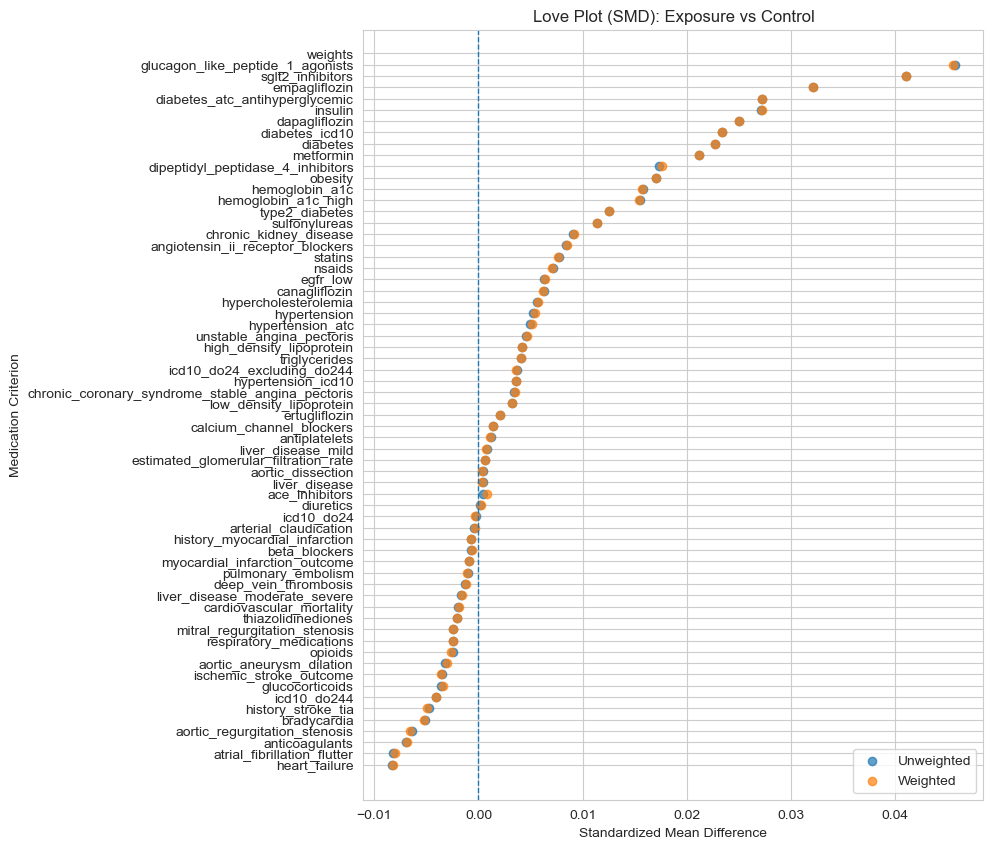

In [47]:
plt.figure(figsize=(8,10))
plt.scatter(pivot_smd['smd'], pivot_smd.index, label='Unweighted', alpha=0.7)
plt.scatter(pivot_weighted_smd['smd'], pivot_weighted_smd.index, label='Weighted', alpha=0.7)
plt.axvline(0, linestyle='--', linewidth=1)
plt.xlabel("Standardized Mean Difference")
plt.ylabel("Medication Criterion")
plt.title("Love Plot (SMD): Exposure vs Control")
plt.legend()
plt.show()

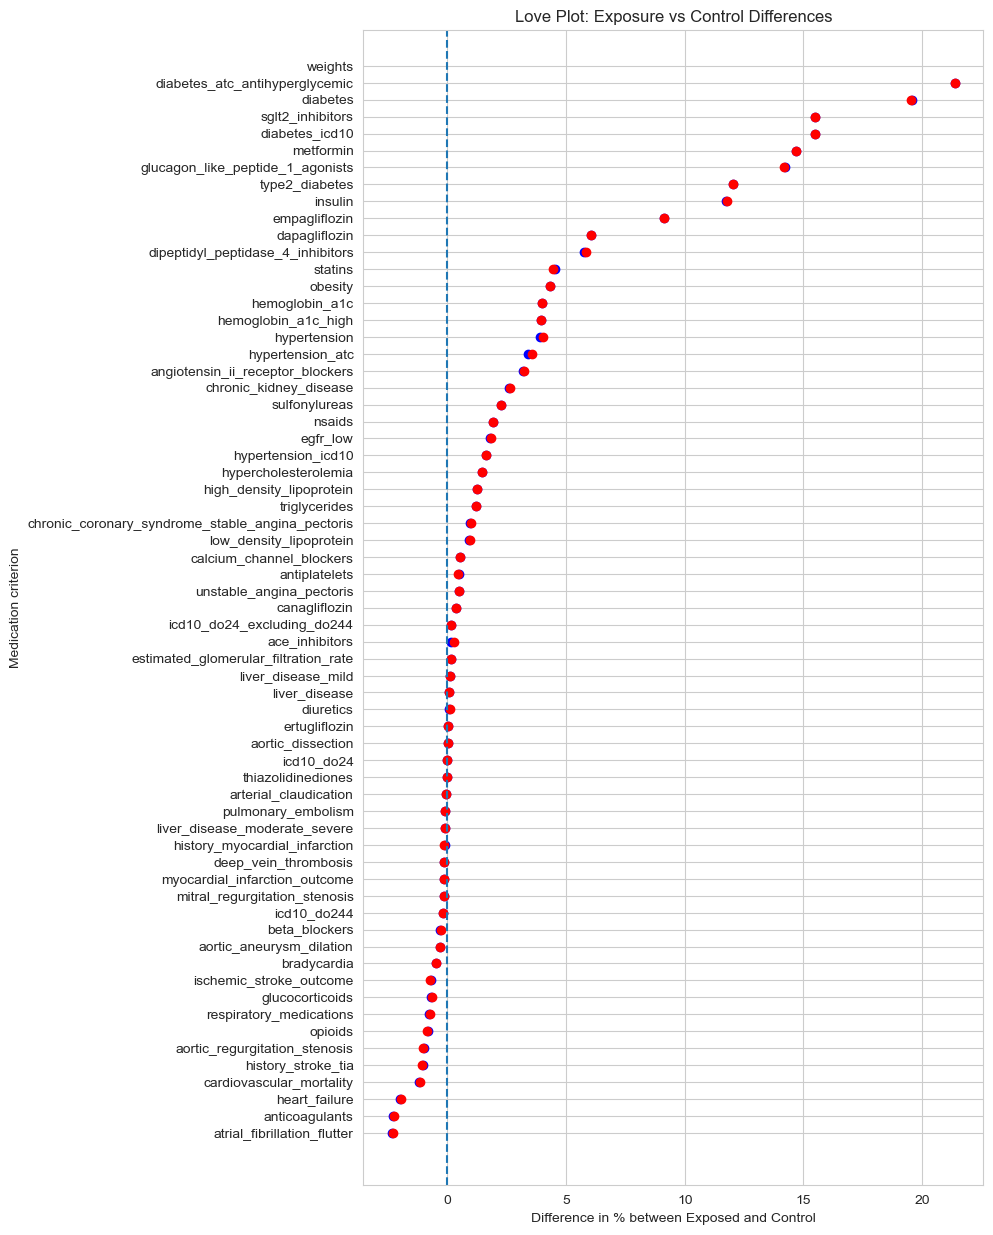

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,15))
plt.scatter(pivot['diff_exposed_control'], pivot.index, color='blue', label='Exposed - Control')
plt.scatter(pivot_weighted['diff_exposed_control'], pivot_weighted.index, color='red', label='Weighted Exposed - Control')
plt.axvline(0, linestyle='--')
plt.xlabel("Difference in % between Exposed and Control")
plt.ylabel("Medication criterion")
plt.title("Love Plot: Exposure vs Control Differences")
plt.show()